https://github.com/FabricioArendTorres/FlowConductor/tree/main

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

# preprocessing
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from msi.utils import preprocessing, plotting, input_output
from msfm.utils import prior, parameters, files, logger, cross_statistics, scales, observation, power_spectra

In [3]:
use_flow = True

if use_flow:
    import torch
    from msi.flow_conductor.likelihood_flow import LikelihoodFlow
    from msi.flow_conductor import architecture
else:
    import tensorflow as tf
    from msi.gaussian_mixture.likelihood_gmm import LikelihoodGMM
    from msi.gaussian_mixture import architecture

# load the summary statistics

In [4]:
# # lensing only
# params = ["Om", "s8", "w0", "Aia", "n_Aia"]
# with_lensing = True
# with_clustering = False
# with_cross_z = True
# with_cross_probe = False

In [5]:
# clustering only
params = ["Om", "s8", "w0", "bg", "n_bg"]
with_lensing = False
with_clustering = True
with_cross_z = True
with_cross_probe = False

In [6]:
# # combined probes
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bg", "n_bg"]
# with_lensing = True
# with_clustering = True
# with_cross_z = True
# with_cross_probe = True

### v6

In [7]:
# # smooth differently

# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")

# # base_dir = "/pscratch/sd/a/athomsen/DESY3/v6/linear_bias"
# base_dir = "/pscratch/sd/a/athomsen/DESY3/v7/linear_bias"

# # out_dir = "/pscratch/sd/a/athomsen/run_files/v6"
# out_dir = "/pscratch/sd/a/athomsen/run_files/v7"

# pca_components = 32
# standardize = True

# # power spectrum scale cuts (in ell)
# n_bins = 33
# l_mins = 8 * [30]

# def angle_to_ell(angles):
#     return list(scales.angle_to_ell(np.array(angles), arcmin=True))

# # # 2 Mpc/h
# # mpc_fwhm = 2
# # l_maxs = angle_to_ell(2 * [7.37791224, 5.03278194, 3.74696505, 3.1436941])

# # # 4 Mpc/h
# # mpc_fwhm = 4
# # l_maxs = angle_to_ell(2 * [14.75582447, 10.06556388, 7.4939301, 6.28738821])

# # # 6 Mpc/h
# # mpc_fwhm = 6
# # l_maxs = angle_to_ell(2 * [22.13373671, 15.09834582, 11.24089514, 9.43108231])

# # # 8 Mpc/h
# # mpc_fwhm = 8
# # l_maxs = angle_to_ell(2 * [29.51164894, 20.13112776, 14.98786019, 12.57477642])

# # # 10 Mpc/h
# # mpc_fwhm = 10
# # l_maxs = angle_to_ell(2 * [36.88956118, 25.1639097, 18.73482524, 15.71847052])

# # # 20 Mpc/h
# # mpc_fwhm = 20
# # l_maxs = angle_to_ell(2 * [73.77912235, 50.3278194, 37.46965048, 31.43694105])

# # 30 Mpc/h
# # mpc_fwhm = 30
# # l_maxs = angle_to_ell(2 * [110.66868353, 75.49172911, 56.20447572, 47.15541157])


# label = f"lensing={with_lensing},clustering={with_clustering},cross_z={with_cross_z},cross_probe={with_cross_probe},pca={pca_components},fwhm={mpc_fwhm},standard={standardize}_hard_cut"

In [8]:
# # discard parts of the non-smoothed bins

# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")

# # base_dir = "/pscratch/sd/a/athomsen/DESY3/v6/linear_bias"
# base_dir = "/pscratch/sd/a/athomsen/DESY3/v7/linear_bias"

# # out_dir = "/pscratch/sd/a/athomsen/run_files/v6"
# out_dir = "/pscratch/sd/a/athomsen/run_files/v7"

# pca_components = 32
# standardize = True

# keep_bins = 4

# label = f"lensing={with_lensing},clustering={with_clustering},cross_z={with_cross_z},cross_probe={with_cross_probe},pca={pca_components},fwhm=None,standard={standardize},bins={keep_bins}_discard_data"

In [9]:
# # one fixed smoothing

# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")

# # base_dir = "/pscratch/sd/a/athomsen/DESY3/v6/linear_bias"
# base_dir = "/pscratch/sd/a/athomsen/DESY3/v7/linear_bias"

# out_dir = "/pscratch/sd/a/athomsen/run_files/v6"
# # out_dir = "/pscratch/sd/a/athomsen/run_files/v7"

# pca_components = 50
# standardize = False

# # power spectrum scale cuts (in ell)
# n_bins = 33
# l_mins = 8 * [30]                

# l_maxs = list(scales.angle_to_ell(np.array([23.03, 16.28, 13.29, 9.4, 65.13, 45.08, 35.17, 29.73]), arcmin=True))
# # l_maxs = list(scales.angle_to_ell(np.array([14.8, 10.1, 7.5, 6.3, 32.6, 22.2, 17.0, 14.3]), arcmin=True))
# # l_maxs = list(scales.angle_to_ell(np.array([10] * 8), arcmin=True))

# label = f"lensing={with_lensing},clustering={with_clustering},cross_z={with_cross_z},cross_probe={with_cross_probe},pca={pca_components}_not_whitened"

### v7

In [10]:
# # smooth differently
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v7/linear_bias.yaml")

# base_dir = "/pscratch/sd/a/athomsen/DESY3/v7/linear_bias"

# out_dir = "/pscratch/sd/a/athomsen/run_files/v7"

# pca_components = 32
# standardize = False

# # power spectrum scale cuts (in ell)
# n_bins = 33
# l_mins = 8 * [30]

# def angle_to_ell(angles):
#     return list(scales.angle_to_ell(np.array(angles), arcmin=True))

# # 6 Mpc/h
# mpc_fwhm = 6
# l_maxs = angle_to_ell(2 * [22.13373671, 15.09834582, 11.24089514, 9.43108231])

# label = f"lensing={with_lensing},clustering={with_clustering},cross_z={with_cross_z},cross_probe={with_cross_probe},pca={pca_components},fwhm={mpc_fwhm},standard={standardize}_hard_cut"

### v9

In [11]:
# smooth differently
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v9/linear_bias.yaml")

base_dir = "/pscratch/sd/a/athomsen/v11desy3/v9/linear_bias"
out_dir = "/pscratch/sd/a/athomsen/run_files/v9"

In [12]:
apply_log = False

standardize = False
# standardize = True

pca_components = 32
# pca_components = 16

# power spectrum scale cuts (in ell)
n_bins = 33
l_mins = 8 * [30]
# l_mins = 8 * [0] 

def angle_to_ell(angles):
    return list(scales.angle_to_ell(np.array(angles), arcmin=True))

# 6 Mpc/h
mpc_fwhm = "6+16"
l_maxs = angle_to_ell([22.1, 15.1, 11.2, 9.4] + [65.1, 44.5, 34.1, 28.5])

label = f"lensing={with_lensing},clustering={with_clustering},cross_z={with_cross_z},cross_probe={with_cross_probe},pca={pca_components},fwhm={mpc_fwhm},standard={standardize}"

#### power spectra

24-07-25 07:37:02 preprocessin INF   Applying scale cuts to the raw Cls 
24-07-25 07:37:02 preprocessin INF   l_mins = [30, 30, 30, 30, 30, 30, 30, 30] 
24-07-25 07:37:02 preprocessin INF   l_maxs = [488.6877828054298, 715.2317880794702, 964.2857142857142, 1148.936170212766, 165.89861751152074, 242.69662921348313, 316.7155425219941, 378.94736842105266] 
24-07-25 07:37:09 input_output INF   Array shapes: 
24-07-25 07:37:09 input_output INF   fiducial/i_example = (40000,) 
24-07-25 07:37:09 input_output INF   fiducial/i_noise   = (40000,) 
24-07-25 07:37:10 input_output INF   fiducial/cls/binned = (40000, 32, 36) 
24-07-25 07:37:10 input_output INF   fiducial/cls/bin_edges = (33, 36) 
24-07-25 07:37:10 input_output INF   grid/cosmo         = (2500, 240, 12) 
24-07-25 07:37:10 input_output INF   grid/i_example     = (2500, 240) 
24-07-25 07:37:10 input_output INF   grid/i_noise       = (2500, 240) 
24-07-25 07:37:10 input_output INF   grid/i_sobol       = (2500, 240) 
24-07-25 07:37:14 in

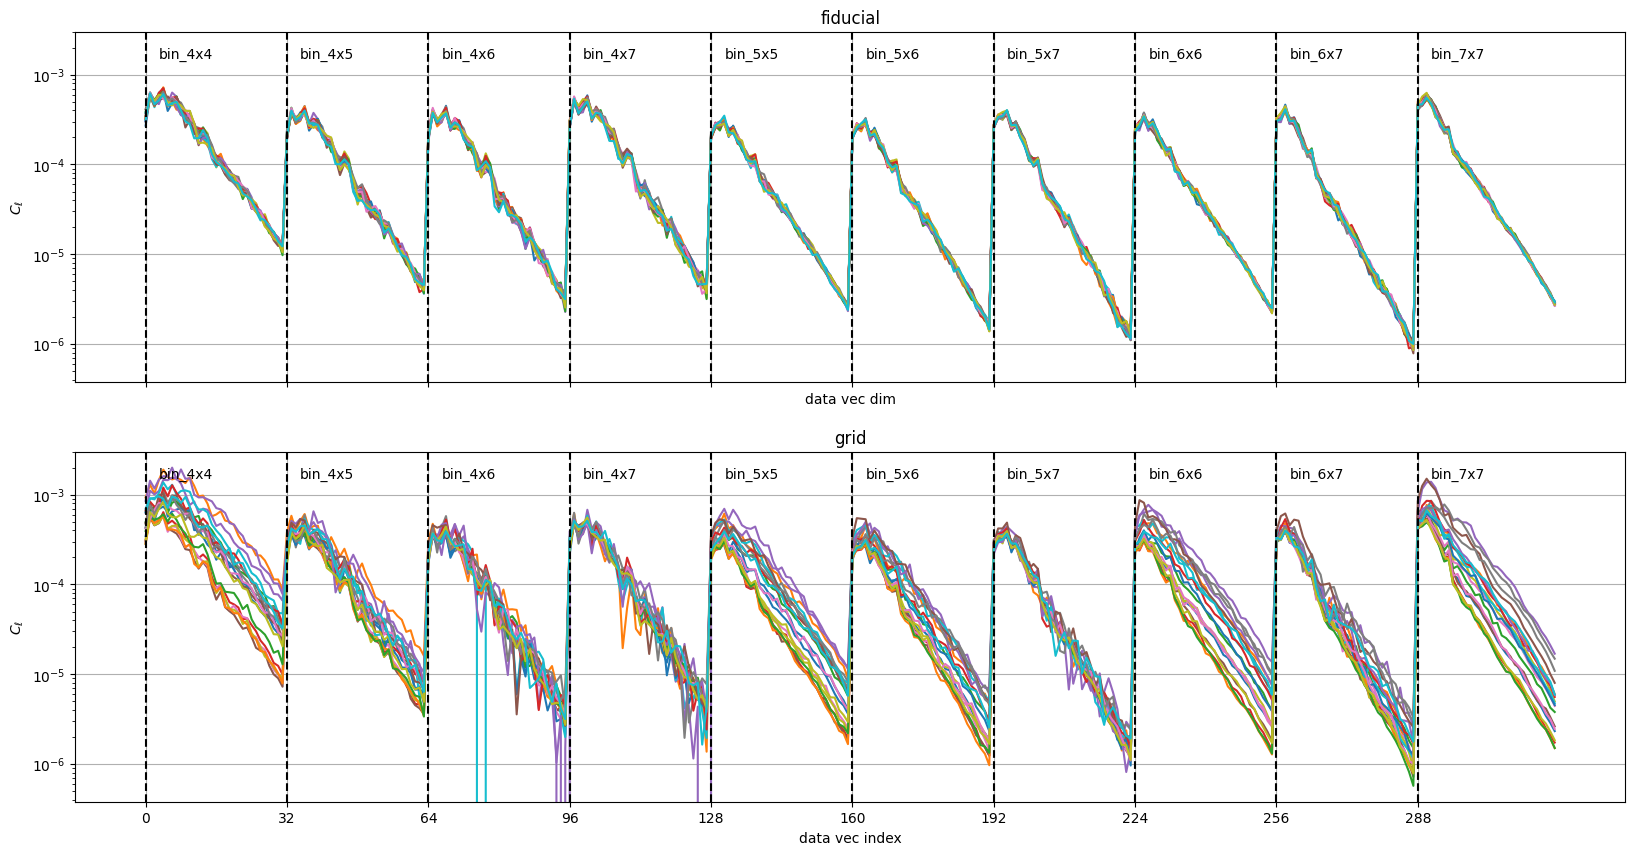

In [13]:
summary = "cls"
# summary = "peaks"

fidu_summs, grid_summs, grid_cosmos, grid_i_sobols, file_dict, scaler, pca = preprocessing.get_reshaped_human_summaries(
    base_dir, 
    summary, 
    # file
    file_label=None,
    # configuration
    conf=conf, 
    params=params,
    concat_example_dim=True,
    # selection
    with_lensing=with_lensing,
    with_clustering=with_clustering,
    with_cross_z=with_cross_z,
    with_cross_probe=with_cross_probe,
    # power spectra: scales
    l_mins=l_mins,
    l_maxs=l_maxs,
    n_bins=n_bins,
    # only_keep_bins=keep_bins,
    # peaks: scales
    scale_indices=None,
    # additional preprocessing
    apply_log=apply_log,
    standardize=standardize,
    pca_components=pca_components,
)

out_dir = os.path.join(out_dir, summary) if (os.path.basename(out_dir) != summary) else out_dir
os.makedirs(out_dir, exist_ok=True)

# likelihood model $p(x|\theta)$

### flow

In [14]:
# input dimensions
x_dim = grid_summs.shape[-1]
theta_dim = grid_cosmos.shape[-1]

# shared hyperparameters
context_embedding_dim = 32

embedding_net = architecture.get_context_embedding_net(
    context_dim=theta_dim,
    context_embedding_dim=context_embedding_dim,
    hidden_dim=64,
    n_blocks=3,
    dropout_probability=0.0,
    use_batch_norm=False,
)    

base_dist = architecture.get_normal_dist(
    feature_dim=x_dim,
)

transform = architecture.get_sigmoids_transform(
    feature_dim=x_dim,
    context_embedding_dim=context_embedding_dim,
    n_layers=4,
    hidden_dim=256,
    svd_kwargs={},
    sigmoids_kwargs={
        "n_sigmoids": 32,
        "num_blocks": 3,
        "dropout_probability": 0.0,
    }
)

# transform = architecture.get_lipschitz_transform(
#     feature_dim=x_dim,
#     context_embedding_dim=context_embedding_dim,
#     n_layers=5,
#     hidden_dim=128,
# )

model = LikelihoodFlow(
    params, 
    conf, 
    embedding_net=embedding_net,
    base_dist=base_dist,
    transform=transform,
    out_dir=out_dir, 
    label=label,
    load_existing=False,
    # load_existing=True,
)

24-07-25 07:37:35 likelihood_b INF   Set up the model directory /pscratch/sd/a/athomsen/run_files/v9/cls/lensing=False,clustering=True,cross_z=True,cross_probe=False,pca=32,fwhm=6+16,standard=False/likelihood_flow 
24-07-25 07:37:35 likelihood_f INF   Initialized the normalizing flow 
24-07-25 07:37:36 likelihood_f INF   Running on device cuda with default float torch.float32 
24-07-25 07:37:36 likelihood_f INF   Initializing fresh weights 


24-07-25 07:37:37 likelihood_f INF   Using a cosine annealing scheduler with lr_min 1e-05 and T_max 100 
100%|████████████████████████████|   | 100/100 [04:31<00:00,  2.71s/it]       lr: 1.00E-05, train: -282.48, vali: -280.56: 
24-07-25 07:42:08 likelihood_f INF   Saved the model to /pscratch/sd/a/athomsen/run_files/v9/cls/lensing=False,clustering=True,cross_z=True,cross_probe=False,pca=32,fwhm=6+16,standard=False/likelihood_flow/likelihood_flow.pt 


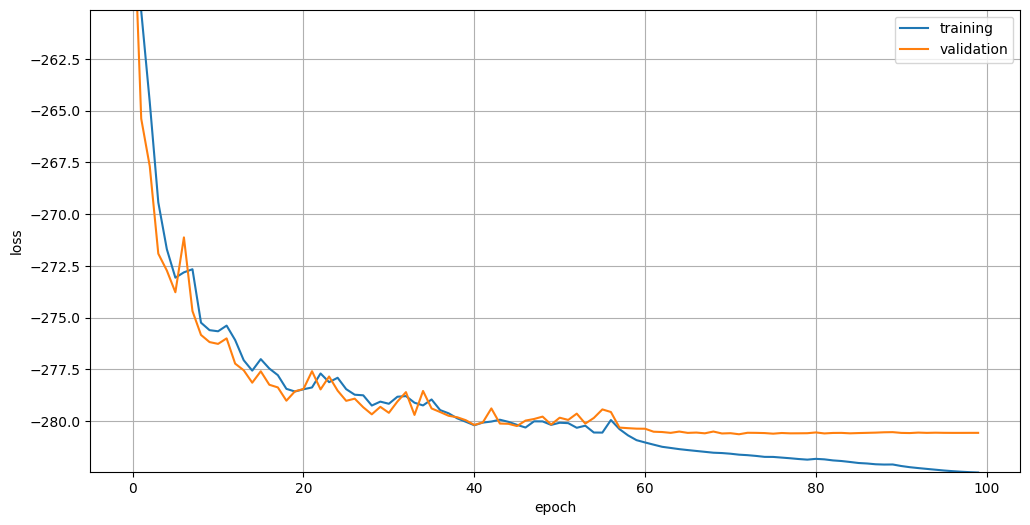

In [15]:
n_samples = 100_000
indices = np.random.randint(0, grid_summs.shape[0], n_samples)

# default to train from scratch with 4 permutations per grid point
model.fit(
    x=grid_summs[indices],
    theta=grid_cosmos[indices],
    n_epochs=100,
    # dataset
    batch_size=10_000,
    vali_split=0.1,
    # optimizer
    learning_rate=1e-2,
    weight_decay=0.0,
    clip_by_global_norm=1.0,
    # scheduler
    scheduler_type="cosine",
    scheduler_kwargs={"eta_min": 1e-5},
    # early stopping
    n_patience_epochs=None,
    min_delta=1e-5,
    save_model=True,
)

In [16]:
# # n_cosmos = 2500
# # n_examples = grid_summs.shape[0]
# # # such that GPU utilization is maximized, but not larger
# # batch_size = 4 * n_cosmos
# # print(f"batch_size = {batch_size} for {n_examples / batch_size} steps per epoch")

# # default to train from scratch with 4 permutations per grid point
# model.fit(
#     x=grid_summs[indices],
#     theta=grid_cosmos[indices],
#     n_epochs=20,
#     # dataset
#     batch_size=batch_size,
#     vali_split=0.1,
#     # optimizer
#     learning_rate=1e-3,
#     weight_decay=0.0,
#     clip_by_global_norm=1.0,
#     # scheduler
#     scheduler_type="cosine",
#     scheduler_kwargs={"eta_min": 1e-5},
#     # early stopping
#     n_patience_epochs=None,
#     min_delta=1e-5,
#     save_model=True,
# )

In [17]:
# model.fit(
#     x=grid_summs,
#     theta=grid_cosmos,
#     n_epochs=100,
#     # dataset
#     batch_size=10000,
#     vali_split=0.1,
#     # optimizer
#     learning_rate=1e-3,
#     weight_decay=0.0,
#     clip_by_global_norm=1.0,
#     # scheduler
#     scheduler_type="cosine",
#     # early stopping
#     n_patience_epochs=None,
#     min_delta=0.0,
#     save_model=True,
# )

In [18]:
# model.fit(
#     x=grid_summs,
#     theta=grid_cosmos,
#     n_epochs=200,
#     # dataset
#     batch_size=10000,
#     vali_split=0.1,
#     # optimizer
#     learning_rate=1e-2,
#     weight_decay=0.0,
#     clip_by_global_norm=1.0,
#     # scheduler
#     scheduler_type="cosine",
#     # early stopping
#     n_patience_epochs=None,
#     min_delta=0.0,
#     save_model=True,
# )

### Gaussian mixture

In [19]:
# layers = architecture.get_gmm_layers(
#     n_x=grid_summs.shape[-1],
#     n_theta=grid_cosmos.shape[-1],
#     n_gaussians=4,
#     n_units=256,
#     n_layers=4,
# )

# model = LikelihoodGMM(
#     params, 
#     conf, 
#     layers=layers,
#     out_dir=out_dir, 
#     label=label,
#     # load_existing=False,
# )

In [20]:
# model.fit(
#     x=grid_summs,
#     theta=grid_cosmos,
#     n_epochs=1000,
#     # dataset
#     batch_size=10000,
#     vali_split=0.1,
#     # optimizer
#     learning_rate=1e-3,
#     weight_decay=0.0,
#     clip_by_global_norm=1.0,
#     learning_rate_min=1e-8,
#     # early stopping
#     n_patience_epochs=100,
#     min_delta=0.001,
#     save_model=True,
# )

### convergence tests

In [21]:
# _, raw_grid_summs, raw_grid_cosmos, _, _, _, _ = preprocessing.get_reshaped_human_summaries(
#     base_dir, 
#     summary, 
#     # file
#     do_plot=False,
#     file_label=None,
#     # configuration
#     conf=conf, 
#     params=params,
#     concat_example_dim=False,
#     # selection
#     with_lensing=with_lensing,
#     with_clustering=with_clustering,
#     with_cross_z=with_cross_z,
#     with_cross_probe=with_cross_probe,
#     # power spectra: scales
#     l_mins=l_mins,
#     l_maxs=l_maxs,
#     n_bins=n_bins,
#     # peaks: scales
#     scale_indices=None,
#     # additional preprocessing
#     standardize=False,
#     apply_log=False,
#     pca_components=pca_components,
# )

# # this applies to the cls, not the peaks. TODO this is a bit hacky
# if raw_grid_cosmos.ndim==3:
#     raw_grid_cosmos = raw_grid_cosmos[:,0,:]

# _ = model.plot_diagnostics(
#     # these must be the raw arrays where the cosmo and example axis are still separate
#     grid_preds_true=raw_grid_summs, 
#     grid_cosmos=raw_grid_cosmos,
#     n_samples=100,
#     do_hist=False,
#     do_dlss=True,
#     do_eecp=True,
#     do_tarp=True,
# )

## observation

### CosmoGrid

In [22]:
# i_obs = 0
# # i_obs = np.argmin(np.sum(np.square(np.median(fidu_preds, axis=0, keepdims=True) - fidu_preds), axis=-1))
# print(f"Using the example index {i_obs}")

# obs_summ = fidu_summs[i_obs]
# obs_fiducial = fidu_summs[i_obs]

# obs_point = {str(param): value for param, value in zip(params, parameters.get_fiducials(params))}
# obs_label = f"fiducial_{i_obs}"

# # obs_pred = np.median(file_dict["fiducial/vali/pred"], axis=0)[:len(params)]
# # obs_point = parameters.get_fiducials(params)
# # obs_label = f"fiducial_median"

# print(obs_summ)

In [23]:
# i_sobol = 1
# i_example = np.arange(grid_i_sobols.shape[0])[grid_i_sobols == 1][0]

# obs_summ = grid_summs[i_example]
# obs_cosmo = grid_cosmos[i_example]

# obs_point = {str(param): value for param, value in zip(params, obs_cosmo)}

# obs_label = f"grid_{i_sobol}"

# print(f"i_sobol = {i_sobol}")
# print(obs_summ)
# print(obs_point)

# fig, ax = plt.subplots(figsize=(20,5))
# ax.plot(obs_summ)
# ax.set(xscale="linear", yscale="linear")


### external

In [29]:
obs_file = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/mock_observations/DESY3_Buzzard_mock.h5"
obs_point = {"Om": 0.286, "s8": 0.82, "w0": -1, "bg": 1.5, "n_bg": 0.5}
obs_label = f"Buzzard"

# obs_file = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/mock_observations/DESY3_Cardinal_mock.h5"
# obs_point = {"Om": 0.286, "s8": 0.82, "w0": -1, "bg": 1.5, "n_bg": 0.5}
# obs_label = f"Cardinal"

n_side = conf["analysis"]["n_side"]
n_pix = conf["analysis"]["n_pix"]
data_vec_pix = files.load_pixel_file(conf)[0]
hp_datapath = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/healpy_data"

with h5py.File(obs_file, "r") as f:
    gc_map = []
    for i in range(1,5):
        gc_map.append(f[f"maglim/galaxy_counts_bin{i}"][:])
    gc_map = np.stack(gc_map, axis=-1)

24-07-25 07:44:11     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_v11_512.h5 


In [30]:
obs_summ = preprocessing.get_preprocessed_cl_observation(
    wl_gamma_map=np.zeros((hp.nside2npix(512),4,2)),
    gc_count_map=gc_map,
    # configuration
    conf=conf,
    # selection
    with_lensing=with_lensing,
    with_clustering=with_clustering,
    with_cross_z=with_cross_z,
    with_cross_probe=with_cross_probe,
    # CLs scale cuts
    l_mins=l_mins,
    l_maxs=l_maxs,
    n_bins=n_bins,
    # additional preprocessing
    apply_log=apply_log,
    scaler=scaler,
    pca=pca,
)

24-07-25 07:44:11     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_v11_512.h5 
24-07-25 07:44:11     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_v11_512.h5 
24-07-25 07:44:24 preprocessin INF   Applying PCA to compress to None components 


In [31]:
# n_side = conf["analysis"]["n_side"]
# n_pix = conf["analysis"]["n_pix"]
# data_vec_pix = files.load_pixel_file(conf)[0]
# hp_datapath = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/healpy_data"

# with h5py.File(obs_file, "r") as f:
#     gc_map = []
#     for i in range(1,5):
#         gc_map.append(f[f"maglim/galaxy_counts_bin{i}"][:])
#     gc_map = np.stack(gc_map, axis=-1)
    
# obs_dv, obs_cl = observation.forward_model_observation_map(
#     wl_gamma_map=np.zeros((hp.nside2npix(512),4,2)),
#     gc_count_map=gc_map,
#     conf=conf,
#     apply_norm=True,
#     with_padding=True,
#     nest=False,
# )

# obs_cl, _ = power_spectra.bin_cls(
#     obs_cl,
#     l_mins=l_mins,
#     # l_mins=8*[0],
#     l_maxs=l_maxs,
#     n_bins=n_bins,
#     n_side=n_side,
#     with_cross=True,
#     per_cross_binning=True,
# )

# # fig, ax = plt.subplots(figsize=(20,5))
# # ax.plot(obs_cl)
# # ax.set(xscale="linear", yscale="log")

# bin_indices, bin_names = cross_statistics.get_cross_bin_indices(
#     with_lensing=with_lensing,
#     with_clustering=with_clustering,
#     with_cross_z=with_cross_z,
#     with_cross_probe=with_cross_probe,
# )
# obs_cl = obs_cl[...,bin_indices]

# # concatenate the bins along the last axis
# obs_cl = np.concatenate([obs_cl[..., i] for i in range(obs_cl.shape[-1])], axis=-1)

# fig, ax = plt.subplots(figsize=(20,5))
# ax.plot(obs_cl, label=obs_label)
# # ax.plot(cls_raw, label="raw CosmoGrid")
# ax.set(xscale="linear", yscale="log")
# ax.legend(loc="best")

# # TODO test
# # obs_cl *= 1.25
# obs_cl *= 1.5625

# obs_pca, _, _ = preprocessing.preprocess_human_summaries(
#     obs_cl[np.newaxis], 
#     apply_log=apply_log,
#     standardize=standardize,
#     pca_components=pca_components,
#     scaler=scaler,
#     pca=pca,
# )
# obs_pca = np.squeeze(obs_pca)

# fig, ax = plt.subplots(figsize=(20,5))
# ax.plot(obs_pca, label=obs_label)
# ax.plot(obs_fiducial, label="fiducial")
# ax.set(xscale="linear", yscale="linear")
# ax.legend()

# obs_summ = obs_pca
# obs_point = {"Om": 0.286, "s8": 0.82, "w0": -1, "bg": 1.5, "n_bg": 0.5}

# print(obs_summ)

## MCMC

In [32]:
posterior_samples = model.sample_posterior(
    obs_summ,
    label=obs_label,
)

24-07-25 07:44:24      mcmc.py INF   Initial values in prior: True 
24-07-25 07:44:24      mcmc.py INF   Starting the burn in MCMC chain (100 steps) 
24-07-25 07:44:33      mcmc.py INF   Starting the main MCMC chain (500 steps) 


100%|██████████| 500/500 [00:43<00:00, 11.58it/s]


24-07-25 07:45:16      mcmc.py INF   Saved the MCMC chain to /pscratch/sd/a/athomsen/run_files/v9/cls/lensing=False,clustering=True,cross_z=True,cross_probe=False,pca=32,fwhm=6+16,standard=False/likelihood_flow/chain_Buzzard.npy 


## plotting

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

24-07-25 07:45:21  plotting.py INF   Saved the plot to /pscratch/sd/a/athomsen/run_files/v9/cls/lensing=False,clustering=True,cross_z=True,cross_probe=False,pca=32,fwhm=6+16,standard=False/likelihood_flow/contours_Buzzard.png 


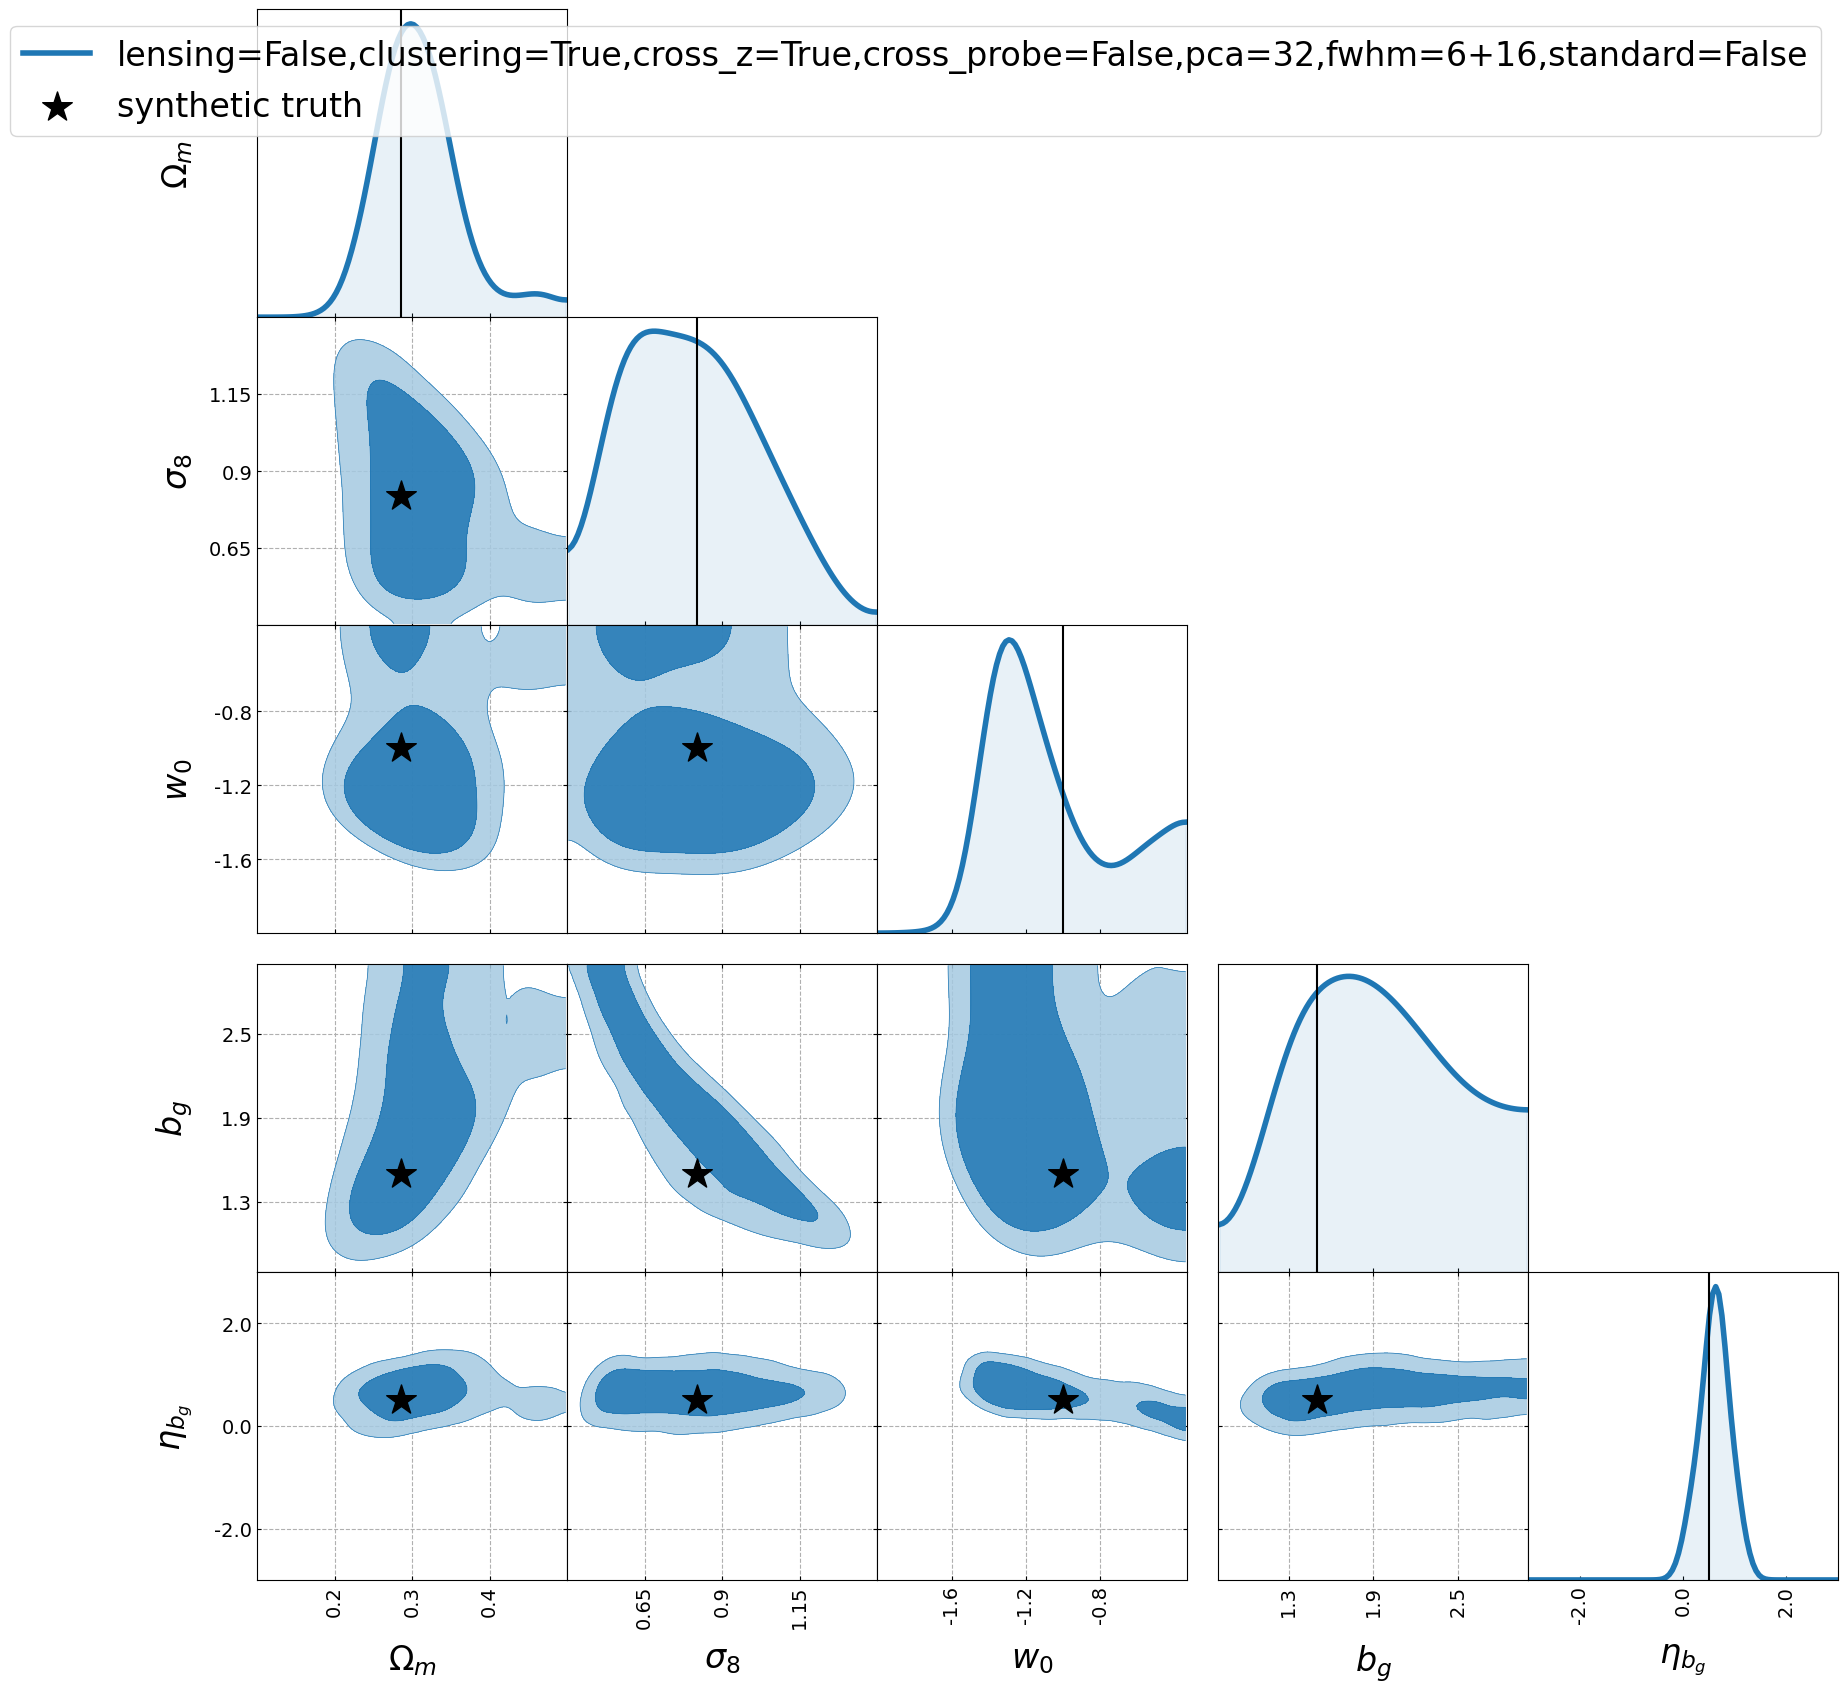

In [33]:
model.plot_contours(
    posterior_samples,
    with_des_chain=False,
    fiducial_point=obs_point,
    label=obs_label,
)

In [ ]:
# for i_obs in range(0,120_000,10_000):
#     obs_pred = grid_summs[i_obs]

#     fiducial_point = {str(param): value for param, value in zip(params, grid_cosmos[i_obs])}
#     print(fiducial_point)
    
#     posterior_samples = model.sample_posterior(
#         obs_pred,
#     )
    
#     model.plot_contours(
#         posterior_samples,
#         fiducial_point=fiducial_point,
#         label=f"grid_{i_obs}"
#     )